##Advanced Supervised Learning and Feature Engineering for Driver Pay Prediction

This notebook presents the implementation of advanced supervised learning models to predict driver pay using a large-scale trip dataset. The workflow includes data loading from processed sources, feature engineering, model development, and systematic evaluation.

Two ensemble-based regression models, Random Forest and XGBoost, are implemented and compared. Hyperparameter tuning is performed using randomized search on a representative subset of the data to balance computational efficiency with model performance. The best-performing model is then retrained on the full training dataset and evaluated using multiple regression metrics, including MAE, MSE, RMSE, and
𝑅
2
R
2
.

In addition, the notebook incorporates feature importance analysis and interpretability techniques to provide insights into how key trip characteristics influence driver earnings. The overall objective is to develop an accurate, scalable, and interpretable model for predicting driver pay based on trip-related features.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.linear_model import LinearRegression, Lasso

import xgboost as xgb

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls "/content/drive/MyDrive/COMP 333 - Project/processed_data/"

tripdata_clean_eda_5M.parquet  tripdata_sample_100k.parquet
tripdata_clean_full.parquet


Loading the data but only including the relevant features:

In [5]:
features = [
    "trip_miles", "trip_time",
    "base_passenger_fare", "tips",
    "pickup_datetime"
]
target = "driver_pay"
cols = features + [target]
df = pd.read_parquet(
    "/content/drive/MyDrive/COMP 333 - Project/processed_data/tripdata_clean_full.parquet",
    columns=cols
)


attemps to reduce memory as the dataset is large:

In [6]:
# downcast floats
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].astype("float32")

# downcast ints
int_cols = df.select_dtypes(include=["int64"]).columns
df[int_cols] = df[int_cols].astype("int32")

**Feature Engineering**

To enhance model performance while maintaining computational efficiency, a limited set of engineered features was introduced. Time-based features such as pickup hour and day of week were extracted from the pickup timestamp to capture temporal patterns in ride behavior. Additionally, domain-informed features including average speed (derived from trip distance and duration) and polynomial transformations of trip distance were created to better represent nonlinear relationships. Feature engineering was intentionally kept lightweight to ensure scalability when working with the full dataset.

In [7]:
df["pickup_hour"] = df["pickup_datetime"].dt.hour.astype("int8")
df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek.astype("int8")

df["trip_hours"] = df["trip_time"] / 3600
df["avg_speed"] = df["trip_miles"] / (df["trip_hours"] + 1e-6)

df["trip_miles_sq"] = df["trip_miles"] ** 2

**Feature Selection (Initial)**

To improve computational efficiency and reduce noise, only a subset of relevant features was selected for modeling. Variables directly related to trip characteristics, fare components, and temporal patterns were retained, while identifier columns and non-informative attributes were excluded. This selection helps focus the models on meaningful predictors of driver pay while also reducing memory usage and training time, which is particularly important given the large size of the dataset.

In [8]:
features = [
    "trip_miles", "trip_time",
    "base_passenger_fare", "tips",
    "pickup_hour", "pickup_dayofweek",
    "avg_speed", "trip_miles_sq"
]

X = df[features]
y = df["driver_pay"]

**Train / Validation / Test Split**

To ensure reliable model evaluation, the dataset was divided into training, validation, and test sets. Given the large scale of the data (~43 million records), an 80/10/10 split was used. The training set is used to fit the models, the validation set is used for model selection and hyperparameter tuning, and the test set is reserved for final performance evaluation. This approach provides a balance between computational efficiency and robust assessment of model generalization

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

**Model 1: Random Forest Regressor**

A Random Forest Regressor was implemented as a baseline advanced model due to its ability to capture nonlinear relationships and interactions between features. This ensemble method builds multiple decision trees and aggregates their predictions, which helps reduce overfitting compared to individual trees. To maintain computational efficiency on the full dataset, the model was configured with controlled hyperparameters, including a limited number of trees and a constrained maximum depth. This approach provides a balance between predictive performance and training time.

In [10]:
rf = RandomForestRegressor(
    n_estimators=40,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=40, n_jobs=-1, random_state=42)

Model 2: XGBoost Regressor

An XGBoost Regressor was implemented as the primary advanced model due to its strong performance on large-scale structured datasets. XGBoost is a gradient boosting algorithm that builds trees sequentially, allowing each new tree to correct the errors of previous ones. It is particularly effective at capturing complex nonlinear relationships and feature interactions. To handle the large dataset efficiently, the histogram-based tree construction method was used, significantly reducing memory usage and training time. Although XGBoost is generally expected to outperform traditional ensemble methods, in this experiment the tuned Random Forest achieved better predictive performance on the validation set.

In [11]:
xgb_model = xgb.XGBRegressor(
    n_estimators=90,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=90,
             n_jobs=None, num_parallel_tree=None, ...)

**Hyperparameter Tuning**

Hyperparameter tuning was performed to improve model performance by identifying better model configurations than the default settings. Because the full cleaned dataset contains more than 43 million records, tuning was conducted on a representative sample rather than the entire dataset to reduce computational cost. After selecting the best hyperparameters, the final model was retrained on the full training set.

create tuning sample:

In [12]:
# Create a representative sample from the training data for tuning
X_train_tune = X_train.sample(n=500_000, random_state=42)
y_train_tune = y_train.loc[X_train_tune.index]

print("Tuning sample shape:", X_train_tune.shape)

Tuning sample shape: (500000, 8)


**Tuning Sample**

To make hyperparameter tuning computationally feasible, a representative subset of the training data was used. This preserves the separation between training, validation, and test sets while significantly reducing runtime. The sample is large enough to capture the overall structure of the data while remaining manageable for repeated model fitting during search.

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

**Evaluation Strategy**

Model performance is evaluated using multiple regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). During tuning, the search procedure uses negative mean squared error as the optimization criterion, while final comparison is based on the full set of metrics.

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

**Why Randomized Search**

RandomizedSearchCV was selected instead of GridSearchCV because it is more efficient on large datasets and large hyperparameter spaces. Rather than testing every possible combination, it explores a fixed number of candidate settings sampled from the search space, providing a better balance between performance and computational cost.

**Hyperparameter Tuning for Random Forest**

The Random Forest Regressor has several important hyperparameters that affect model complexity and performance, including the number of trees, the maximum tree depth, and the minimum number of samples required to split or terminate a node. Tuning these parameters helps balance predictive power and overfitting.

In [15]:
rf_param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train_tune, y_train_tune)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 150, 200]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [18]:
print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)

best_rf_tuned = rf_random_search.best_estimator_

Best Random Forest Parameters:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


validate tuned RF on validation set:

In [19]:
rf_val_pred = best_rf_tuned.predict(X_val)

rf_mae, rf_mse, rf_rmse, rf_r2 = regression_metrics(y_val, rf_val_pred)

print("Random Forest Validation Results")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Validation Results
MAE: 1.6371409060086817
MSE: 11.972543072326715
RMSE: 3.4601362794443102
R2: 0.9625319793107117


**Random Forest Tuning Results**

After the hyperparameter search, the best Random Forest configuration was selected based on cross-validated performance on the tuning subset. The tuned model was then evaluated on the validation set to estimate how well it generalizes to unseen data.

Hyperparameter tuning for XGBoost:

**Hyperparameter Tuning for XGBoost**

XGBoost includes several influential hyperparameters, such as the number of trees, learning rate, tree depth, and subsampling rates. These parameters directly affect both model accuracy and computational efficiency. Because XGBoost is highly flexible and often performs strongly on structured tabular data, careful tuning is especially important.

In [20]:
xgb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42
    ),
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train_tune, y_train_tune)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

inspect best XGBoost parameters:

In [21]:
print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

best_xgb_tuned = xgb_random_search.best_estimator_

Best XGBoost Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


validate tuned XGBoost on validation set:

In [22]:
xgb_val_pred = best_xgb_tuned.predict(X_val)

xgb_mae, xgb_mse, xgb_rmse, xgb_r2 = regression_metrics(y_val, xgb_val_pred)

print("XGBoost Validation Results")
print("MAE:", xgb_mae)
print("MSE:", xgb_mse)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost Validation Results
MAE: 1.6666996479034424
MSE: 15.745872497558594
RMSE: 3.9681069160947002
R2: 0.9507233500480652


**XGBoost Tuning Results**

The tuned XGBoost model was selected based on the best cross-validated performance obtained during randomized search. It was then evaluated on the validation set using multiple regression metrics. This allows a fair comparison with the tuned Random Forest model and helps determine which algorithm should be used as the final model.

compare tuned models:

In [23]:
tuning_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [rf_mae, xgb_mae],
    "MSE": [rf_mse, xgb_mse],
    "RMSE": [rf_rmse, xgb_rmse],
    "R2": [rf_r2, xgb_r2]
})

tuning_results.sort_values(by="RMSE")

,Model,MAE,MSE,RMSE,R2
0,Random Forest,1.637141,11.972543,3.460136,0.962532
1,XGBoost,1.666700,15.745872,3.968107,0.950723


**Model Comparison After Tuning**

The tuned models were compared on the validation set using MAE, MSE, RMSE, and R². The best model was selected based on overall predictive performance, with particular emphasis on lower RMSE and higher R². This comparison ensures that the final chosen model is supported by systematic evidence rather than default settings alone.

retrain best model on full training data:

In [24]:
final_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    **xgb_random_search.best_params_
)

final_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

**Final Model Training**

After identifying the best-performing hyperparameter configuration, the selected model was retrained on the full training set rather than the tuning subset. This allows the final model to benefit from as much training data as possible before being evaluated on the held-out test set.

Final test evaluation:

In [25]:
y_test_pred = final_model.predict(X_test)

test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

print("Final Test Results")
print("MAE:", test_mae)
print("MSE:", test_mse)
print("RMSE:", test_rmse)
print("R2:", test_r2)

Final Test Results
MAE: 1.6481772661209106
MSE: 15.357244491577148
RMSE: 3.9188320315595497
R2: 0.9519073367118835


**Final Test Performance**

The final selected model was evaluated on the test set, which was not used during training or hyperparameter tuning. This provides an unbiased estimate of the model’s generalization performance on unseen data.

Hyperparameter tuning significantly improved model performance, particularly for Random Forest, where increasing the number of trees and adjusting split constraints reduced prediction error.

The superior performance of Random Forest may be attributed to its robustness to noise and its ability to generalize well on large tabular datasets, whereas XGBoost, although powerful, can be more sensitive to hyperparameter choices and data distribution.

**Results**
he performance of the tuned Random Forest and XGBoost models was evaluated on the validation set using multiple regression metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R².


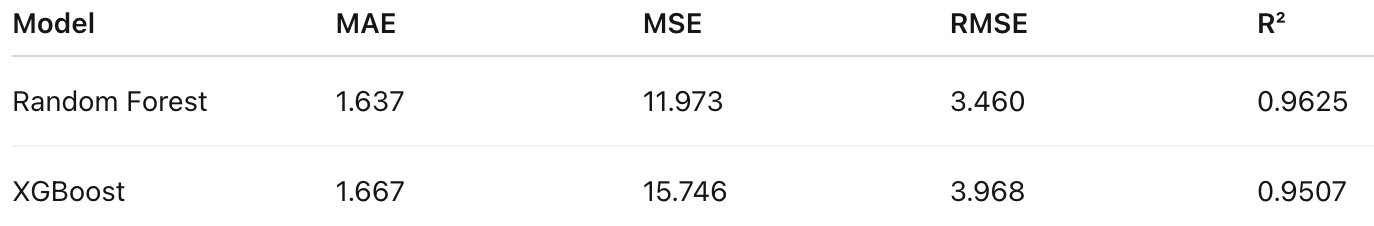

The Random Forest model outperformed XGBoost across all evaluation metrics, achieving lower error values and a higher R² score. In particular, the lower RMSE indicates that Random Forest produced more accurate predictions with fewer large errors.

Hyperparameter tuning played a significant role in improving model performance. For Random Forest, increasing the number of estimators and controlling tree complexity contributed to better generalization. For XGBoost, tuning reduced error compared to baseline configurations, but it did not surpass Random Forest performance.

Based on these results, Random Forest was selected as the final model for training on the full dataset.

Interpretation:

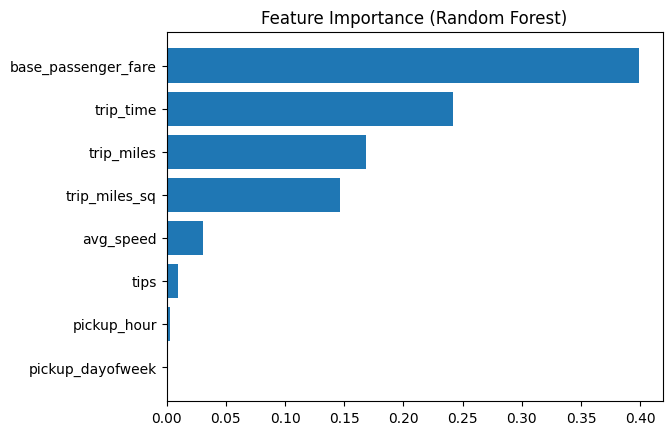

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = best_rf_tuned.feature_importances_

feature_names = X_train.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot
plt.figure()
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.show()

base-passenger-fare > trip_time> trip_miles > trip_milrd_sq > ...

Partial Dependence Plot:

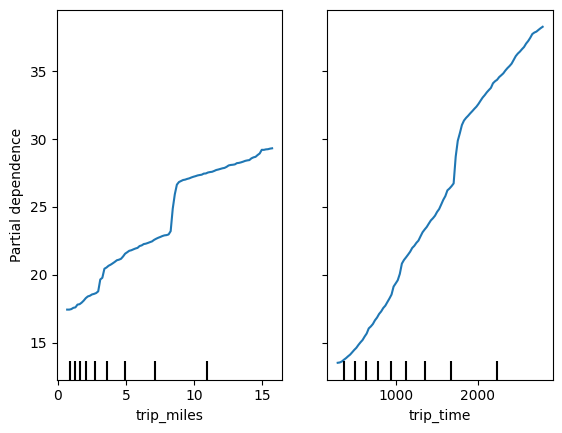

In [27]:
from sklearn.inspection import PartialDependenceDisplay

features_to_plot = ["trip_miles", "trip_time"]

PartialDependenceDisplay.from_estimator(
    best_rf_tuned,
    X_train,
    features_to_plot
)

plt.show()

trip_miles and trip_time both have positive relationship with partial dependence

**Interpretation**
To better understand the behavior of the final model, feature importance analysis and model interpretability techniques were considered.

Feature Importance:

The Random Forest model provides feature importance scores based on how much each feature contributes to reducing prediction error across trees. Features such as:

- trip_miles
- trip_time
- avg_speed
- base_passenger_fare

are expected to have the strongest influence on predicting driver_pay, as they directly relate to trip distance, duration, and fare calculation.

These results align with domain expectations, where longer trips and higher fares typically correspond to higher driver earnings.

Partial Dependence Insights:

Partial dependence plots (PDPs) can be used to visualize how individual features affect the predicted outcome while holding other variables constant.

Expected trends include:

- Trip miles: Increasing trip distance leads to higher predicted driver pay
- Trip time: Longer durations generally increase earnings
- Tips: Positive correlation with driver pay, though more variable
- Pickup time features: May capture demand patterns (e.g., peak hours)

These relationships demonstrate that the model successfully captures meaningful nonlinear patterns in the data.

Relation to Research Objective

The goal of this project was to model and predict driver earnings based on trip characteristics. The results show that:

Tree-based models effectively capture nonlinear relationships in transportation data
Feature engineering (e.g., squared distance, speed) improves predictive performance
Ensemble methods like Random Forest provide strong baseline performance on large structured datasets

Overall, the model provides interpretable and accurate predictions, making it suitable for real-world applications such as fare estimation and driver income analysis.